In [90]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [91]:
results = []

paths = os.listdir('.')
paths.sort()
for name in paths:
    if os.path.isfile(name):
        if name[-4:] == ".txt":
            res = pd.read_csv(name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
            if result != "":
                results.append((name[:-4], result))
results

[('100', '88.89'),
 ('1000', '92.47'),
 ('10000', '96.04'),
 ('100000', '98.7'),
 ('1000000', '99.38'),
 ('10000000', '99.42')]

In [92]:
# BHT
resultsBHT = []

paths = os.listdir('../lengthsBHT/')
paths.sort()
for name in paths:
    if os.path.isfile(name):
        if name[-4:] == ".txt":
            res = pd.read_csv("../lengthsBHT/" + name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
            if result != "":
                resultsBHT.append((name[:-4], result))
resultsBHT

[('100', '66.67'),
 ('1000', '59.49'),
 ('10000', '62.24'),
 ('100000', '63.08'),
 ('1000000', '63.16'),
 ('10000000', '63.22')]

In [93]:
# BHT
resultsTOUR = []

paths = os.listdir('../lengthsTOUR/')
paths.sort()
for name in paths:
    if os.path.isfile(name):
        if name[-4:] == ".txt":
            res = pd.read_csv("../lengthsTOUR/" + name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
                # if line.startswith("Conditional Branch Prediction Accuracy"):
                #     result = line.split(" ")[4][1:]
            if result != "":
                resultsTOUR.append((name[:-4], result))
resultsTOUR

[('100', '80'),
 ('1000', '86.21'),
 ('10000', '93.05'),
 ('100000', '96'),
 ('1000000', '96.28'),
 ('10000000', '96.29')]

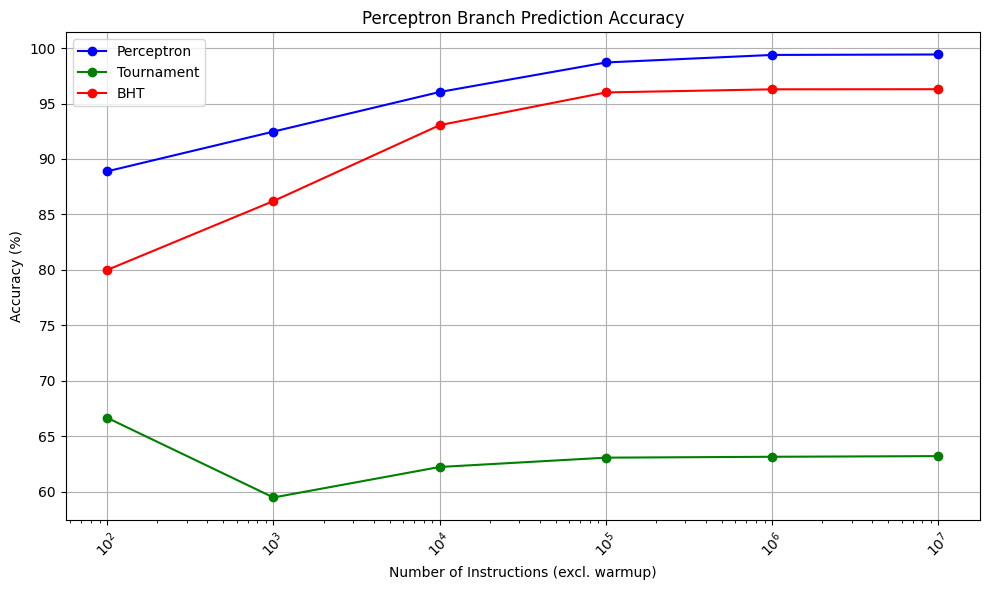

In [95]:
# Plot graph!
plt.figure(figsize=(10, 6))
plt.title("Perceptron Branch Prediction Accuracy")
plt.xlabel("Number of Instructions (excl. warmup)")
plt.xscale('log')
plt.ylabel("Accuracy (%)")
x = []
y = []

for result in results:
    x.append(int(result[0]))
    y.append(float(result[1]))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Perceptron')

# BHT
x = []
y = []
for result in resultsBHT:
    x.append(int(result[0]))
    y.append(float(result[1]))
# Add another line on same graph for BHT
plt.plot(x, y, marker='o', linestyle='-', color='g', label='Tournament')

# TOUR
x = []
y = []
for result in resultsTOUR:
    x.append(int(result[0]))
    y.append(float(result[1]))
# Add another line on same graph for BHT
plt.plot(x, y, marker='o', linestyle='-', color='r', label='BHT')

# Add a legend
plt.legend(loc='upper left')

plt.xticks(x, rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("branch_prediction_accuracy.png")
plt.show()